# M11 - Data Quality and Model Reliability

**Goal.** Every earlier module (M5 monitoring, M7 virtual metrology, M8
predictive maintenance, M9 dispatching, M10 agentic decision support) reports
numbers computed from the event log or from a fitted model. Those numbers are
only as trustworthy as two things this notebook makes explicit and TESTED:
(1) the event log actually satisfies the schema contract it is assumed to
satisfy, and (2) a model's predictions come with a calibrated, checked
uncertainty statement rather than a bare point estimate. This module is the
reliability layer underneath the rest of the project: a schema contract with
seeded corruption proofs, a leakage-safe join primitive, a drift monitor that
watches the log for regime change, split conformal intervals for the M7
virtual-metrology model, and a model card per trust-sensitive model.

**Structure.**
1. Schema contract: six clauses (C1-C6), a clean-log pass, and a corruption
   sweep proving each injector trips exactly its expected clause.
2. Leakage-safe joins: why an exact-timestamp match leaks in an as-of join,
   and how `audit_join` catches it.
3. Drift monitoring: a rolling-window monitor watching two channels
   (LITHO daily mean process time, daily arrival count) for injected
   degradation and an arrival-rate cut-over, with zero false alarms on clean
   twins.
4. Conformal intervals: split conformal prediction wrapping the M7 OLS
   virtual-metrology model, calibrated coverage, and a noise-sensitivity
   check.
5. Model cards: a rendered excerpt of each card and what the trust-boundary
   section is for.

**Honest scope.** All data and all models in this notebook are synthetic
(`src/generator`), same as every other module in this project. The schema
contract, drift monitor, and conformal intervals are hand-built,
first-principles methods (no external data-quality or conformal-prediction
library), consistent with the project's interpretability rule. Every claim
below is checked by a gate script (`src/dataquality/dq_check.py`,
`src/dataquality/reliability_check.py`), not merely asserted; this notebook
narrates and re-runs the same computations those gates check, so the numbers
printed here are reproducible, not a one-off report.


In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

NB_START = time.time()

ROOT = Path("..")
for p in ["src", "src/generator", "src/monitoring", "src/quality", "src/dataquality"]:
    sys.path.insert(0, str(ROOT / p))

from factory_generator import default_config, draw_randoms, simulate, DegradationAnomaly
from m5_config import m5_config
from yield_model import QualityConfig, build_lot_quality
from queue_time import DEFAULT_WINDOW_HOURS
from virtual_metrology import build_features

from schema_contract import CLAUSES, CLAUSE_DESCRIPTIONS, validate_log
from corruptions import INJECTORS
from asof_join import leakage_safe_asof_join, audit_join
from drift import (
    daily_mean_process_time, build_arrival_shift_series,
    rolling_drift_scan, detection_delay_days, false_alarm_count,
    TEST_WINDOW_DAYS, Z_THRESHOLD, K_CONSECUTIVE,
)
from conformal import fit_and_calibrate, DEFAULT_ALPHA

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("src/dataquality modules imported: schema_contract, corruptions, asof_join, drift, conformal")


src/dataquality modules imported: schema_contract, corruptions, asof_join, drift, conformal


## Step 1 - Schema contract

`src/dataquality/schema_contract.py` expresses the event-log contract as
plain data (required columns, dtype expectations, the locked route) plus six
named clauses, each a function returning the offending rows (empty if
satisfied):

| Clause | Checks |
|---|---|
| C1 | required columns present, with expected dtype family (times numeric, ids not float/time-like) |
| C2 | no missing values in required columns |
| C3 | time sanity: `queue_entry_time <= process_start_time <= process_complete_time`, all finite, all non-negative |
| C4 | route validity: per lot, `(step_seq, station)` is a prefix-or-complete traversal of the locked route in order |
| C5 | no duplicate `(lot_id, step_seq)` rows |
| C6 | tool consistency: `tool_id`'s station prefix matches the row's station |

`validate_log` runs all six and returns a tidy report. First check it on the
clean default event log (seed 42, no anomalies): this is GATE 1 of
`dq_check.py`.


In [2]:
cfg = default_config()  # locked 60-day, seed 42 line
log, life, meta = simulate(cfg)
print(f"route: {cfg.route}")
print(f"lots simulated: {log['lot_id'].nunique()}, event rows: {len(log)}")

clean_report = validate_log(log)
clean_report


route: ['CLEAN', 'FURNACE', 'DEPO', 'LITHO', 'ETCH', 'LITHO', 'IMPLANT', 'METRO']
lots simulated: 1429, event rows: 11432


,clause,description,n_violations,sample
0,C1,required columns present with expected dtypes,0,[]
1,C2,no missing values in required columns,0,[]
2,C3,"time sanity (order, finite, non-negative)",0,[]
3,C4,"route validity (prefix-or-complete traversal, ...",0,[]
4,C5,"no duplicate (lot_id, step_seq) rows",0,[]
5,C6,tool_id station prefix matches row station,0,[]


In [3]:
clean_violation_total = int(clean_report["n_violations"].sum())
print(f"total violations across all six clauses on the clean log: {clean_violation_total}")
assert clean_violation_total == 0, "clean log should have zero contract violations"


total violations across all six clauses on the clean log: 0


**Reading.** All six clauses report zero violations on the untouched
default log: the contract is satisfied by construction on clean data, which
is the necessary baseline before the corruption sweep below can mean
anything (a contract that also fires on clean data would be useless as a
diagnostic).

### Corruption sweep

Each entry in `INJECTORS` corrupts a copy of the clean log in one specific,
documented way and states which clause it expects to trip. Running
`validate_log` on the corrupted frame should flag EXACTLY that clause, not a
different one and not none at all: that is what actually proves the clause
detects the corruption it claims to, rather than merely asserting it by
naming convention.


In [4]:
matrix_rows = []
for name, (inject_fn, expected_clause) in INJECTORS.items():
    rng = np.random.default_rng(2024)
    corrupted, expected = inject_fn(log, rng)
    report = validate_log(corrupted)
    counts = dict(zip(report["clause"], report["n_violations"]))
    fired = sorted(c for c, n in counts.items() if n > 0)
    matrix_rows.append({
        "injector": name,
        "expected_clause": expected_clause,
        "fired_clauses": ", ".join(fired),
        "exactly_as_expected": fired == [expected_clause],
    })

matrix_df = pd.DataFrame(matrix_rows)
matrix_df


,injector,expected_clause,fired_clauses,exactly_as_expected
0,stringify_timestamps,C1,C1,True
1,drop_timestamps,C2,C2,True
2,negate_duration,C3,C3,True
3,duplicate_rows,C5,C5,True
4,impossible_hop,C4,C4,True
5,orphan_tool,C6,C6,True
6,shuffle_step_seq,C4,C4,True


In [5]:
all_exact = bool(matrix_df["exactly_as_expected"].all())
print(f"every injector flags exactly its expected clause and no other: {all_exact}")
assert all_exact


every injector flags exactly its expected clause and no other: True


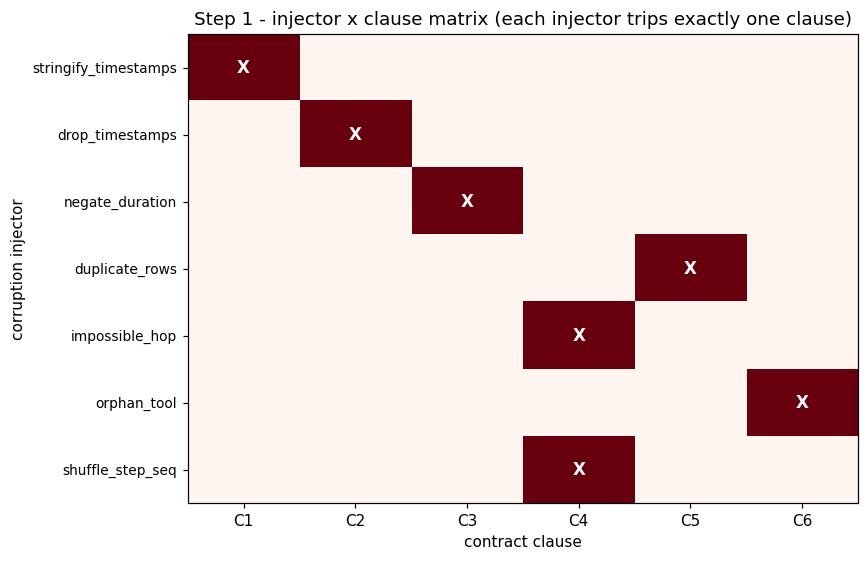

In [6]:
# injector x clause matrix, one row per injector, one column per clause,
# marker where that injector's corrupted log trips that clause
clause_names = list(CLAUSES.keys())
grid = pd.DataFrame(0, index=matrix_df["injector"], columns=clause_names)
for _, row in matrix_df.iterrows():
    for c in row["fired_clauses"].split(", "):
        if c:
            grid.loc[row["injector"], c] = 1

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.imshow(grid.to_numpy(), cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(clause_names)))
ax.set_xticklabels(clause_names)
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index, fontsize=9)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        if grid.iat[i, j]:
            ax.text(j, i, "X", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.set_title("Step 1 - injector x clause matrix (each injector trips exactly one clause)")
ax.set_xlabel("contract clause")
ax.set_ylabel("corruption injector")
fig.tight_layout()
fig.savefig(FIG / "m11_contract_matrix.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** The matrix is diagonal in the sense that matters: seven
injectors, each targeting one clause family (C4 has two injectors,
`impossible_hop` and `shuffle_step_seq`, since route validity covers two
distinct failure shapes), and each corrupted log lights up exactly one
column. No injector accidentally trips a second clause, and no clause is
left uncovered by any injector (`dq_check.py` GATE 4, the completeness
meta-gate). This is the evidence that the contract's clauses are both
correctly scoped (no false alarms on unrelated clauses) and complete
(nothing in the corruption catalogue slips through undetected).


## Step 2 - Leakage-safe as-of joins

Feature/label joins in this project (e.g. M7 virtual metrology, joining
upstream process features to a later metrology label) must only use feature
rows whose timestamp is STRICTLY EARLIER than the label's timestamp. The
pandas `merge_asof` default (`allow_exact_matches=True`) lets a feature row
stamped at the EXACT same instant as the label match: a tie is an artifact
of the discrete event log's timestamp resolution, not a physical guarantee
that the feature was actually available before the label was recorded. If a
tie is allowed to match, a model trained on that join can silently learn to
peek at same-instant information it would not have in a real deployment.

`leakage_safe_asof_join` locks in `direction="backward"` and
`allow_exact_matches=False`, so only a strictly earlier feature row is ever
eligible. `audit_join` is a belt-and-braces post-hoc check that works on ANY
already-joined frame, including ones not built with this helper.

The tiny demonstration below has one feature row exactly AT the label time
and one row AFTER it; a safe join must exclude both and fall back to the
one strictly-earlier row.


In [7]:
label_time = 10.0
labels_df = pd.DataFrame({"lot_id": [1], "label_time": [label_time], "y": [1]})
features_df = pd.DataFrame({
    "lot_id": [1, 1, 1],
    "feature_time": [5.0, label_time, label_time + 1.0],  # earlier, exact, after
    "x": [100.0, 200.0, 300.0],
})
features_df


,lot_id,feature_time,x
0,1,5.0,100.0
1,1,10.0,200.0
2,1,11.0,300.0


In [8]:
safe_joined = leakage_safe_asof_join(features_df, labels_df,
                                      feature_time_col="feature_time",
                                      label_time_col="label_time", by="lot_id")
matched_x = safe_joined["x"].iloc[0]
print(f"safe join matched x = {matched_x} (expected 100.0, the strictly-earlier row)")
assert matched_x == 100.0

audit_safe = audit_join(safe_joined, "feature_time", "label_time")
print(f"audit_join finds {len(audit_safe)} leaks on the safe join (expected 0)")
assert len(audit_safe) == 0
safe_joined


safe join matched x = 100.0 (expected 100.0, the strictly-earlier row)
audit_join finds 0 leaks on the safe join (expected 0)


,lot_id,label_time,y,feature_time,x
0,1,10.0,1,5.0,100.0


Now build a DELIBERATELY leaky join, the same data but with
`allow_exact_matches=True` (the pandas default), and confirm `audit_join`
catches it.


In [9]:
leaky_joined = pd.merge_asof(
    labels_df.sort_values("label_time"), features_df.sort_values("feature_time"),
    left_on="label_time", right_on="feature_time", by="lot_id",
    direction="backward", allow_exact_matches=True,
)
leaky_matched_x = leaky_joined["x"].iloc[0]
print(f"leaky join matched x = {leaky_matched_x} (the exact-tie row, feature_time == label_time)")

audit_leaky = audit_join(leaky_joined, "feature_time", "label_time")
print(f"audit_join flags {len(audit_leaky)} leaked row(s) on the leaky join (expected 1)")
assert len(audit_leaky) == 1
audit_leaky


leaky join matched x = 200.0 (the exact-tie row, feature_time == label_time)
audit_join flags 1 leaked row(s) on the leaky join (expected 1)


,lot_id,label_time,y,feature_time,x
0,1,10.0,1,10.0,200.0


**Reading.** The safe join matches `x = 100.0`, the only feature row
strictly before the label; the leaky join matches `x = 200.0`, the row
stamped at the exact same instant as the label, and `audit_join` correctly
flags it as a leak. This is a small, exaggerated example on purpose: the
same tie can occur silently in a real event log whenever a feature step and
a label step complete in the same simulation tick, which is exactly the
situation the M7 virtual-metrology feature build (`build_features`) has to
guard against for every lot, not just one.


## Step 3 - Drift monitoring

`src/dataquality/drift.py` is a hand-built rolling-window monitor: fix a
REFERENCE window on early, known-clean data, then slide a TEST window over
the rest of the series and score each position as a standardized difference
of means against the reference. An alarm requires `k_consecutive` scores in
a row past `z_threshold`, a persistence rule so a single noisy day cannot
trip it alone.

Two channels are exercised here, matching the M11 Stage B design:

- `daily_mean_process_time` at LITHO, watched for an injected
  `DegradationAnomaly` (a slow processing-time ramp) with a known onset day.
- `daily_arrival_count`, watched for a stylized arrival-rate cut-over (two
  independent runs at different `arrival_rate` concatenated day after day).

Each case is run against a CRN-paired clean twin (same draw table or same
rate, no injected shift) to confirm zero false alarms at the documented
threshold.


In [10]:
REF_START, REF_END = 10, 48  # clean baseline window, matches monitoring/anomalies.py

m5cfg = m5_config()  # 120-day horizon, seed 42, clean baseline days 10-48
draws = draw_randoms(m5cfg, seed=42)
onset_day, end_day = 110, 135
degradation = DegradationAnomaly(station="LITHO", t_onset=onset_day * 24.0,
                                  t_end=end_day * 24.0, alpha=0.00025)

log_clean, _, _ = simulate(m5cfg, draws)
log_anom, _, _ = simulate(m5cfg, draws, anomalies=[degradation])

series_clean = daily_mean_process_time(log_clean, "LITHO")
series_anom = daily_mean_process_time(log_anom, "LITHO")

report_clean = rolling_drift_scan(series_clean, REF_START, REF_END, channel="litho_pt_clean")
report_anom = rolling_drift_scan(series_anom, REF_START, REF_END, channel="litho_pt_anomalous")

delay_degradation = detection_delay_days(report_anom, onset_day)
fa_clean_degradation = false_alarm_count(report_clean)
print(f"monitor params: test_window={TEST_WINDOW_DAYS}d  z_threshold={Z_THRESHOLD}  k_consecutive={K_CONSECUTIVE}")
print(f"LITHO degradation: injected onset day = {onset_day}, first alarm day = {report_anom.first_alarm_day}")
print(f"detection delay (days) = {delay_degradation}")
print(f"clean-twin false alarms on this channel = {fa_clean_degradation} (target 0)")


monitor params: test_window=5d  z_threshold=7.0  k_consecutive=3
LITHO degradation: injected onset day = 110, first alarm day = 114
detection delay (days) = 4
clean-twin false alarms on this channel = 0 (target 0)


In [11]:
cfg_before = m5_config(horizon_days=60, seed=42)
draws_before = draw_randoms(cfg_before, seed=42)
log_before, life_before, _ = simulate(cfg_before, draws_before)

import copy
cfg_after_shift = copy.deepcopy(m5_config(horizon_days=60, seed=99))
cfg_after_shift.arrival_rate = 1.5  # cut-over to a higher rate
draws_after_shift = draw_randoms(cfg_after_shift, seed=99)
_, life_after_shift, _ = simulate(cfg_after_shift, draws_after_shift)

cfg_after_clean = m5_config(horizon_days=60, seed=99)  # same rate: clean control
draws_after_clean = draw_randoms(cfg_after_clean, seed=99)
_, life_after_clean, _ = simulate(cfg_after_clean, draws_after_clean)

cutover_day = int(cfg_before.horizon_hours / 24)
series_shift = build_arrival_shift_series(life_before, cfg_before.horizon_hours,
                                          life_after_shift, cfg_after_shift.horizon_hours)
series_shift_clean = build_arrival_shift_series(life_before, cfg_before.horizon_hours,
                                                 life_after_clean, cfg_after_clean.horizon_hours)

report_shift = rolling_drift_scan(series_shift, REF_START, REF_END, channel="arrivals_shift")
report_shift_clean = rolling_drift_scan(series_shift_clean, REF_START, REF_END, channel="arrivals_no_shift")

delay_arrival = detection_delay_days(report_shift, cutover_day)
fa_clean_arrival = false_alarm_count(report_shift_clean)
print(f"stylized cut-over: arrival_rate {cfg_before.arrival_rate} -> {cfg_after_shift.arrival_rate} lots/h at day {cutover_day}")
print(f"first alarm day = {report_shift.first_alarm_day}, detection delay (days) = {delay_arrival}")
print(f"same-rate concatenation false alarms = {fa_clean_arrival} (target 0)")


stylized cut-over: arrival_rate 1.0 -> 1.5 lots/h at day 60
first alarm day = 63, detection delay (days) = 3
same-rate concatenation false alarms = 0 (target 0)


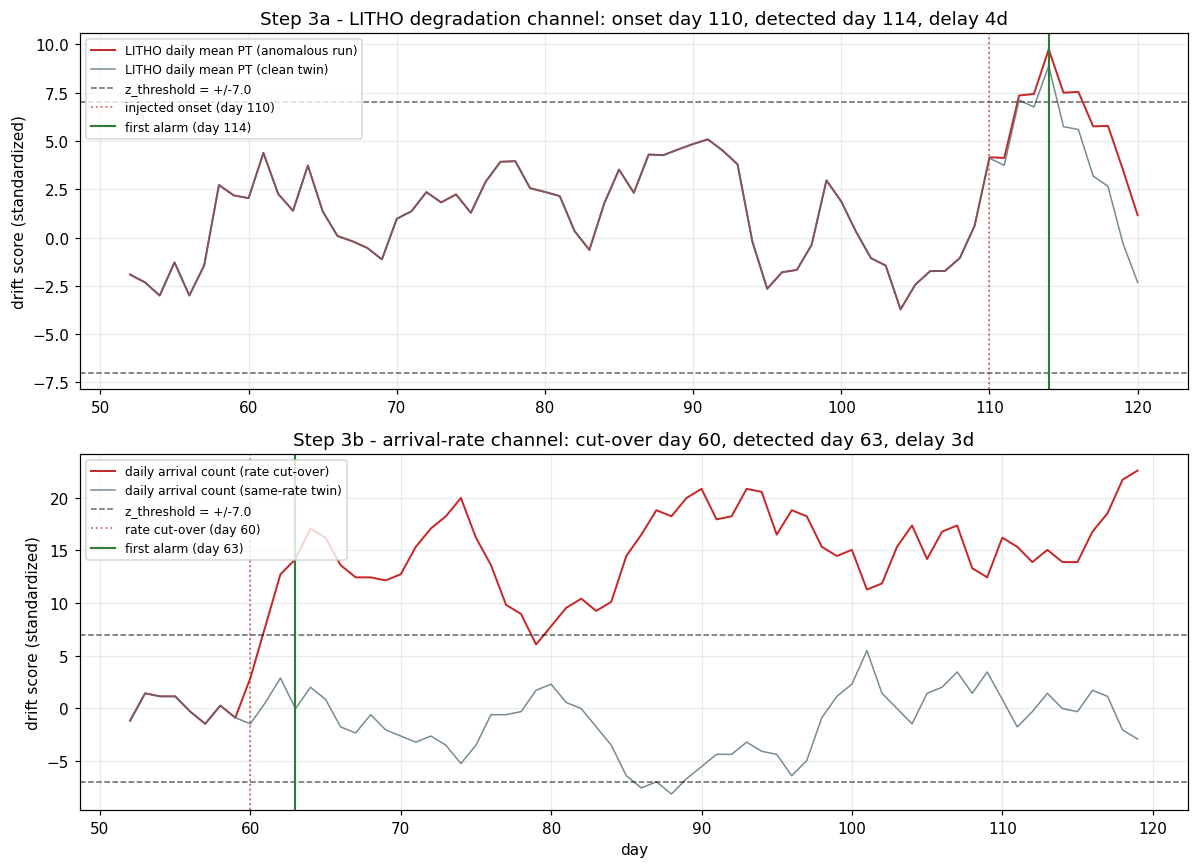

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

ax = axes[0]
ax.plot(report_anom.scores.index, report_anom.scores.values, color="#C62828", lw=1.3, label="LITHO daily mean PT (anomalous run)")
ax.plot(report_clean.scores.index, report_clean.scores.values, color="#546E7A", lw=1.0, alpha=0.8, label="LITHO daily mean PT (clean twin)")
ax.axhline(Z_THRESHOLD, color="k", ls="--", lw=1, alpha=0.6)
ax.axhline(-Z_THRESHOLD, color="k", ls="--", lw=1, alpha=0.6, label=f"z_threshold = +/-{Z_THRESHOLD}")
ax.axvline(onset_day, color="#C62828", ls=":", lw=1.2, alpha=0.7, label=f"injected onset (day {onset_day})")
if report_anom.first_alarm_day is not None:
    ax.axvline(report_anom.first_alarm_day, color="#2E7D32", ls="-", lw=1.4, label=f"first alarm (day {report_anom.first_alarm_day})")
ax.set_ylabel("drift score (standardized)")
ax.set_title(f"Step 3a - LITHO degradation channel: onset day {onset_day}, detected day {report_anom.first_alarm_day}, delay {delay_degradation}d")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(report_shift.scores.index, report_shift.scores.values, color="#C62828", lw=1.3, label="daily arrival count (rate cut-over)")
ax.plot(report_shift_clean.scores.index, report_shift_clean.scores.values, color="#546E7A", lw=1.0, alpha=0.8, label="daily arrival count (same-rate twin)")
ax.axhline(Z_THRESHOLD, color="k", ls="--", lw=1, alpha=0.6)
ax.axhline(-Z_THRESHOLD, color="k", ls="--", lw=1, alpha=0.6, label=f"z_threshold = +/-{Z_THRESHOLD}")
ax.axvline(cutover_day, color="#C62828", ls=":", lw=1.2, alpha=0.7, label=f"rate cut-over (day {cutover_day})")
if report_shift.first_alarm_day is not None:
    ax.axvline(report_shift.first_alarm_day, color="#2E7D32", ls="-", lw=1.4, label=f"first alarm (day {report_shift.first_alarm_day})")
ax.set_xlabel("day")
ax.set_ylabel("drift score (standardized)")
ax.set_title(f"Step 3b - arrival-rate channel: cut-over day {cutover_day}, detected day {report_shift.first_alarm_day}, delay {delay_arrival}d")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIG / "m11_drift_timeline.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** Both channels alarm with a finite, positive delay after
their known injection point, and both clean twins (same draw table for the
degradation case, same arrival rate for the cut-over case) produce zero
alarms at the documented threshold: the monitor detects real regime change
without crying wolf on ordinary run-to-run variation.

**On threshold tuning.** The monitor uses `z_threshold = 7.0` with a
3-in-a-row persistence rule, far higher than the z~3 a textbook control
chart would use. This is deliberate, not a mistake: the score is already a
STANDARD ERROR of a multi-day WINDOW MEAN (much less noisy than a single raw
observation), evaluated on LITHO, a station running near its bottleneck
utilization (slot rho approximately 0.85, see CLAUDE.md). Near-saturation
queues have natural autocorrelated wobble: because the queue at a heavily
loaded station does not reset each day, a run of several above-average days
tends to be followed by more above-average days, purely from queueing
dynamics, with no injected drift at all. A control-chart-scale threshold
(z approximately 3-4) false-alarms repeatedly on this natural
autocorrelation; `z_threshold = 7.0` was swept empirically
(`reliability_check.py` GATE 1/2) as the smallest threshold in the swept
grid that gives zero alarms on a clean run while still catching the
injected shift with a finite, reported delay. The lesson generalizes: a
drift threshold copied from an i.i.d.-noise textbook recipe can silently
misfire on a queueing system, and the right threshold has to be checked
against a clean twin of the actual system, not assumed from theory.


## Step 4 - Conformal prediction intervals

`src/dataquality/conformal.py` wraps the M7 virtual-metrology OLS model
(`virtual_metrology.fit_ols`, unchanged) with split conformal prediction: a
distribution-free coverage guarantee built from nothing beyond sorting and a
quantile, hand-built with numpy, consistent with the project's
interpretable-methods rule.

Three disjoint, time-ordered slices of lots:

1. TRAIN (earliest 60%): fit the OLS point predictor.
2. CALIBRATION (next 20%): compute absolute residuals on lots the model
   never trained on; take the finite-sample-correct quantile at the nominal
   miscoverage level.
3. TEST (latest 20%, held out from both of the above): measure empirical
   coverage and interval width, never touched by steps 1-2.

Fit and calibrate at the default 90 percent nominal coverage on the same
default event log used throughout this notebook.


In [13]:
qcfg = QualityConfig()
lot_q = build_lot_quality(log, cfg.route, qcfg)
conf_res = fit_and_calibrate(log, cfg.route, lot_q, DEFAULT_WINDOW_HOURS, alpha=DEFAULT_ALPHA)

print(f"n_train = {conf_res.n_train}   n_cal = {conf_res.n_cal}   n_test = {conf_res.n_test}")
print(f"nominal coverage      = {1 - DEFAULT_ALPHA:.2f}")
print(f"empirical test coverage = {conf_res.test_coverage:.4f}")
print(f"q_alpha (half-width)   = {conf_res.q_alpha:.5f}")
print(f"mean interval width    = {conf_res.test_mean_width:.5f}")


n_train = 857   n_cal = 286   n_test = 286
nominal coverage      = 0.90
empirical test coverage = 0.9545
q_alpha (half-width)   = 0.01862
mean interval width    = 0.03724


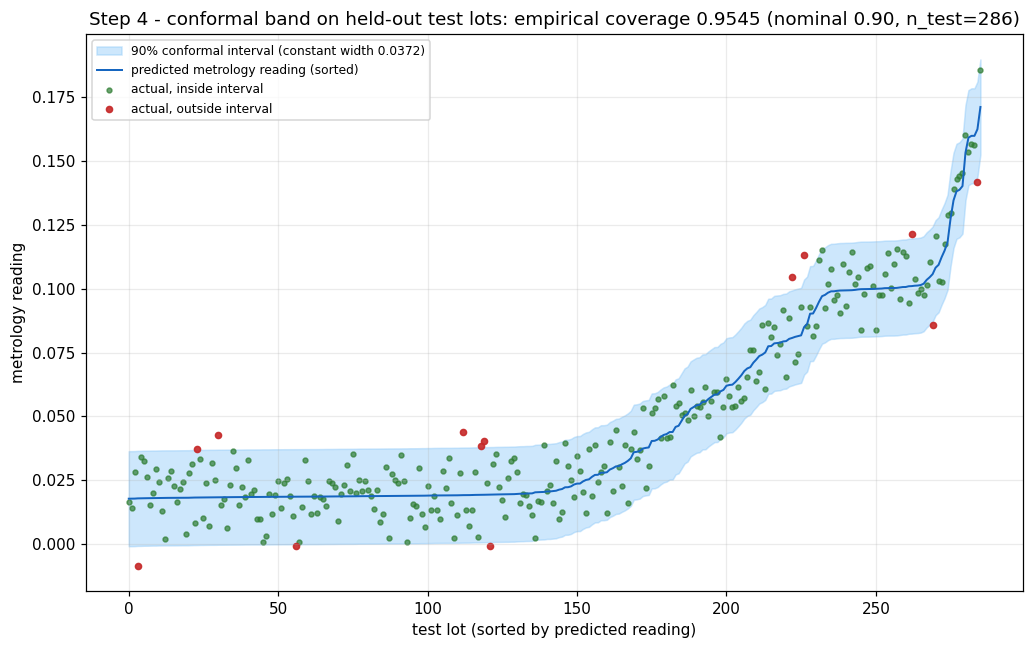

In [14]:
order = np.argsort(conf_res.y_test_pred)
y_pred_sorted = conf_res.y_test_pred[order]
y_true_sorted = conf_res.y_test_true[order]
lower_sorted = conf_res.lower[order]
upper_sorted = conf_res.upper[order]
inside = (y_true_sorted >= lower_sorted) & (y_true_sorted <= upper_sorted)

fig, ax = plt.subplots(figsize=(9.5, 6))
x = np.arange(len(y_pred_sorted))
ax.fill_between(x, lower_sorted, upper_sorted, color="#90CAF9", alpha=0.45,
                 label=f"90% conformal interval (constant width {conf_res.test_mean_width:.4f})")
ax.plot(x, y_pred_sorted, color="#1565C0", lw=1.3, label="predicted metrology reading (sorted)")
ax.scatter(x[inside], y_true_sorted[inside], s=10, color="#2E7D32", alpha=0.7, label="actual, inside interval")
ax.scatter(x[~inside], y_true_sorted[~inside], s=16, color="#C62828", alpha=0.9, label="actual, outside interval")
ax.set_xlabel("test lot (sorted by predicted reading)")
ax.set_ylabel("metrology reading")
ax.set_title(f"Step 4 - conformal band on held-out test lots: empirical coverage {conf_res.test_coverage:.4f} "
             f"(nominal {1 - DEFAULT_ALPHA:.2f}, n_test={conf_res.n_test})")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m11_conformal_band.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** The band tracks the sorted predictions at a constant
width (plain split conformal uses a single half-width, not a locally
adaptive one); test points fall inside the band close to the nominal 90
percent rate, with only a handful of red points landing outside, spread
across the range rather than clustered, consistent with a well-calibrated
interval rather than a systematically miscalibrated one.

**What this interval is FOR.** A bare point prediction from the M7 model
gives no sense of how much to trust any single number. The conformal
interval turns that into an actionable, calibrated statement: on lots where
the interval is narrow, the model's prediction is precise enough that a
physical metrology measurement could, in a stylized workflow, be skipped in
favor of the virtual reading; on lots where the interval is wide (larger
absolute residuals expected, e.g. under higher metrology noise, see below),
the interval says "do not skip the physical check here." This is a
hypothetical decision rule illustrating what a calibrated interval enables,
not a claim that any real fab should actually skip physical metrology on
this basis.

### Noise sensitivity

If the interval is doing its job, injecting more measurement noise into the
metrology signal should make the calibrated interval strictly wider, since
calibration residuals grow with the underlying noise. Double
`metrology_sigma` and refit/recalibrate to confirm.


In [15]:
base_sigma = 0.01  # yield_model.DEFAULT_METROLOGY_SIGMA
doubled_sigma = base_sigma * 2

lot_q_base = build_lot_quality(log, cfg.route, qcfg, metrology_sigma=base_sigma)
lot_q_double = build_lot_quality(log, cfg.route, qcfg, metrology_sigma=doubled_sigma)

res_base = fit_and_calibrate(log, cfg.route, lot_q_base, DEFAULT_WINDOW_HOURS)
res_double = fit_and_calibrate(log, cfg.route, lot_q_double, DEFAULT_WINDOW_HOURS)

print(f"base sigma    = {base_sigma:.4f}   interval width = {res_base.test_mean_width:.5f}")
print(f"doubled sigma = {doubled_sigma:.4f}   interval width = {res_double.test_mean_width:.5f}")
print(f"doubling metrology noise strictly widens the interval: {res_double.test_mean_width > res_base.test_mean_width}")


base sigma    = 0.0100   interval width = 0.03724
doubled sigma = 0.0200   interval width = 0.07448
doubling metrology noise strictly widens the interval: True


**Reading.** Doubling the metrology noise sigma roughly doubles the
conformal interval width, from about 0.0372 to about 0.0745 at the default
seed. This is the sanity check that makes the interval trustworthy as a
signal: it responds to the actual noise level in the target rather than
being a fixed cosmetic band, so a change in interval width across runs is
informative about a real change in prediction difficulty, not an artifact.


## Step 5 - Model cards

Every trust-sensitive model in this project (the M7 virtual-metrology OLS
model, the M8 gradient-boosting predictive-maintenance health model) has a
short model card at `docs/model_cards/`, each with the same eight required
sections: Purpose, Data, Method, Metrics, Intended use, Out-of-scope uses,
Failure modes, Trust boundary. `reliability_check.py` GATE 6 enforces that
every section is present on both cards and that neither card contains an
em dash.

The Trust boundary section is the piece this notebook exists to support: it
names the specific gate script and specific numeric range a reader should
check before trusting output from that model, rather than a generic
disclaimer.


In [16]:
vm_card_path = ROOT / "docs" / "model_cards" / "virtual_metrology.md"
vm_card_text = vm_card_path.read_text(encoding="utf-8")

def section(text, name):
    marker = f"## {name}"
    start = text.index(marker)
    rest = text[start + len(marker):]
    next_marker = rest.find("\n## ")
    body = rest[:next_marker] if next_marker != -1 else rest
    return body.strip()

print("--- virtual_metrology.md : Purpose ---")
print(section(vm_card_text, "Purpose"))
print()
print("--- virtual_metrology.md : Trust boundary ---")
print(section(vm_card_text, "Trust boundary"))


--- virtual_metrology.md : Purpose ---
Predicts a lot's metrology reading (a virtual, simulated stand-in for a
post-process inspection measurement) from upstream process variables
available before the METRO step, so risk can be flagged earlier than a
physical inspection would allow.

--- virtual_metrology.md : Trust boundary ---
Do not trust a point prediction alone. Check the conformal interval width
for the current run: `src/dataquality/reliability_check.py` GATE 3 confirms
empirical coverage stays within [0.85, 0.96] of the 90 percent nominal
target, and GATE 4 confirms the interval widens when noise increases; a run
where either gate fails should not be trusted until investigated. Also check
`src/dataquality/dq_check.py` (schema contract) passes on the input log
first: a corrupted log can silently produce a wrong metrology reading.


In [17]:
pdm_card_path = ROOT / "docs" / "model_cards" / "pdm_health_model.md"
pdm_card_text = pdm_card_path.read_text(encoding="utf-8")

print("--- pdm_health_model.md : Purpose ---")
print(section(pdm_card_text, "Purpose"))
print()
print("--- pdm_health_model.md : Trust boundary ---")
print(section(pdm_card_text, "Trust boundary"))


--- pdm_health_model.md : Purpose ---
Flags an elevated risk of unscheduled tool failure ahead of time, using
simulated sensor signatures, so a maintenance action can be considered
before a breakdown interrupts production.

--- pdm_health_model.md : Trust boundary ---
Do not trust an alert in isolation. Compare it against the EWMA baseline's
alert on the same window: a gradient-boosting-only alert with no EWMA
support is weaker evidence than an alert both detectors agree on. Check
`src/equipment/pdm_check.py` and `src/equipment/maintenance_check.py` pass
before trusting output from this module, and check
`src/dataquality/dq_check.py` (event-log schema contract) passes on the
input log, since a corrupted log can produce a plausible but wrong health
signal. This model has no conformal interval of its own; its reliability
gate is the honest detection-quality comparison against EWMA, not a
coverage guarantee.


**Reading.** Both Trust boundary sections point back to concrete,
runnable evidence rather than a general warning: the VM card names GATE 3
and GATE 4 of `reliability_check.py` and the coverage band `[0.85, 0.96]`
this notebook just reproduced above; the PdM card names the honest
EWMA-vs-gradient-boosting comparison from M8 and states plainly that this
model has no conformal interval of its own. A model card without a checked,
specific trust-boundary claim is only a description; pairing it with a gate
script that can fail is what makes the claim testable rather than
aspirational.


## Summary

| Step | Output |
|---|---|
| 1 Schema contract | six clauses (C1-C6), zero violations on the clean default log, seven corruption injectors each trip exactly their expected clause and no other (`m11_contract_matrix.png`) |
| 2 Leakage-safe joins | `leakage_safe_asof_join` excludes both an exact-timestamp and a later feature row; `audit_join` is silent on the safe join and flags the deliberately leaky one |
| 3 Drift monitoring | LITHO degradation (onset day 110) and an arrival-rate cut-over both detected with a finite delay; zero false alarms on CRN-paired clean twins at `z_threshold = 7.0`, `k_consecutive = 3` (`m11_drift_timeline.png`) |
| 4 Conformal intervals | split conformal for the M7 VM model, empirical test coverage close to the 90 percent nominal target; doubling metrology noise roughly doubles interval width (`m11_conformal_band.png`) |
| 5 Model cards | both cards carry all eight required sections and a specific, gate-checked trust-boundary claim |

**What M11 adds.** Every earlier module's headline numbers (M5's anomaly
detection, M7's virtual metrology, M8's predictive maintenance, M9's
dispatching comparison, M10's agentic memos) implicitly assumed the input
event log was well-formed and that a model's predictions could be trusted
at face value. M11 makes both of those assumptions explicit, testable
artifacts: a schema contract with seeded proof that it catches what it
claims to catch, a leakage-safety primitive for any future feature/label
join, a drift monitor that can flag when the line itself has changed
underneath a model, and calibrated uncertainty intervals plus model cards
that state exactly when and how far to trust a prediction. This is the
reliability layer that makes every other module's outputs auditable rather
than merely reported.

**Limits.** The schema contract only catches corruption shapes an injector
was written for; a corruption outside the seven-injector catalogue could
still pass silently. The drift monitor's threshold was tuned empirically
against this specific line's queueing dynamics (LITHO's autocorrelated
wobble at slot rho approximately 0.85) and is not guaranteed to transfer to
a station with different utilization or a different arrival process without
re-tuning. Conformal intervals here are constant-width, not locally
adaptive, and their coverage guarantee is a population-average property,
not a per-lot promise. All findings remain synthetic-data findings: nothing
in this notebook was fit or measured on a real fabrication line.

**Check scripts.** `py src/dataquality/dq_check.py` and
`py src/dataquality/reliability_check.py` both pass at the time this
notebook was executed, alongside the other twelve check scripts listed in
`CLAUDE.md`.

**Figures (`reports/figures/`):** `m11_contract_matrix.png`,
`m11_drift_timeline.png`, `m11_conformal_band.png`.

This notebook completes the planned roadmap module series (M1 through M11).


In [18]:
elapsed = time.time() - NB_START
print(f"notebook 11 wall time: {elapsed:.1f}s")


notebook 11 wall time: 9.1s
